In [23]:
#dataset = https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [3]:
#downloading dataset:
kagglehub.dataset_download('mczielinski/bitcoin-historical-data')

100%|██████████| 95.7M/95.7M [02:20<00:00, 715kB/s]

Extracting files...


'C:\\Users\\Lenovo\\.cache\\kagglehub\\datasets\\mczielinski\\bitcoin-historical-data\\versions\\319'

In [8]:
#importing dataset:
df = pd.read_csv(r'C:\\Users\\Lenovo\\.cache\\kagglehub\\datasets\\mczielinski\\bitcoin-historical-data\\versions\\319\btcusd_1-min_data.csv').dropna()
df.head()

,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


In [11]:
#defining x and y:
x = df.select_dtypes(include = 'number').drop(columns = ['Close'])
y = df['Close']

In [12]:
#splitting data for training and testing:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

In [13]:
#making an ai model:
model = LinearRegression()

In [14]:
#training ai model:
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
#testing ai model based on testing data:
predictions = model.predict(x_test)

# **Evaluating AI Model**

Text(0, 0.5, 'Predicted Values')

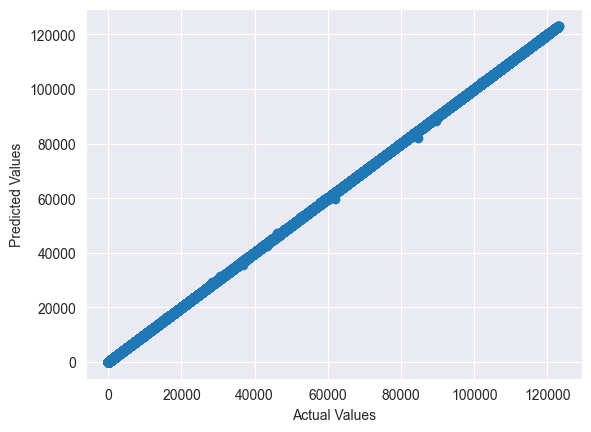

In [16]:
#scatter plot of actual values vs predicted values:
plt.scatter(y_test, predictions)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

<Axes: xlabel='Close', ylabel='Count'>

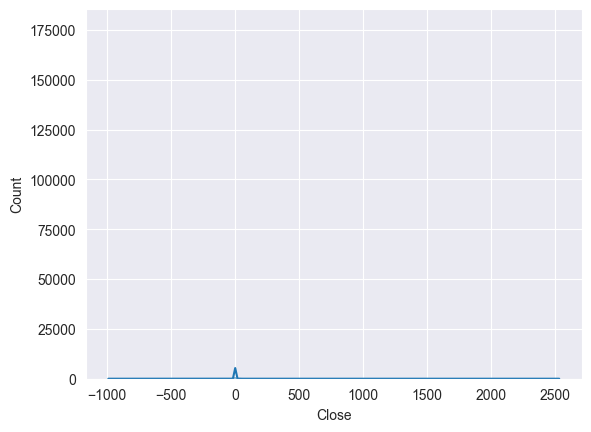

In [17]:
#histogram of residuals:
residuals = y_test - predictions
sns.histplot(residuals, kde = True)

In [19]:
#mae, rmse:
mae = metrics.mean_absolute_error(y_test, predictions)
rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
mae_percentage = (mae / y.mean()) * 100
rmse_percentage = (rmse / y.mean()) * 100
print(f'mae percentage = {mae_percentage}')
print(f'rmse percentage = {rmse_percentage}')

print('\nnote = mae percentage between 0 - 5% is good, 5 - 10% is acceptable, above 10% is bad\nrmse percentage between 0 - 7% is good, 7 - 12% is acceptable, above 12% is bad')

#our ai model is perfect

mae percentage = 0.020830758469769072
rmse percentage = 0.05592089867668754

note = mae percentage between 0 - 5% is good, 5 - 10% is acceptable, above 10% is bad
rmse percentage between 0 - 7% is good, 7 - 12% is acceptable, above 12% is bad


# **Conclusion**

In [22]:
pd.DataFrame(data = model.coef_, index = x.columns, columns = ['Coefficient'])

#bitcoin price increases by 7.594426e-01 when Low is increased by 1 unit

,Coefficient
Timestamp,-3.173653e-10
Open,-5.545360e-01
High,7.950885e-01
Low,7.594426e-01
Volume,1.285673e-03


In [24]:
#custom prediction:
custom_prediction = model.predict(pd.DataFrame([[int(time.time()), 115002.1, 116829.2, 114267.3, 1000.0]], columns = ['Timestamp', 'Open', 'High', 'Low', 'Volume']))
print(f'lets suppose tomorrow exactly at this time opening price of btc is 115002.1, high is 116829.2, low is 114267.3, volume is 1000. then closing price of btc shall be = {custom_prediction}')

lets suppose tomorrow exactly at this time opening price of btc is 115002.1, high is 116829.2, low is 114267.3, volume is 1000. then closing price of btc shall be = [115897.41769154]
